### Učitavanje i pretprocesiranje skupa podataka

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('datasets/dogs.csv')

In [3]:
df

,breed,height,weight
0,Border Collie,20,45
1,Boston Terrier,16,20
2,Brittany Spaniel,18,35
3,Bullmastiff,27,120
4,Chihuahua,8,8
5,German Shepherd,25,78
6,Golden Retriever,23,70
7,Great Dane,32,160
8,Portuguese Water Dog,21,50
9,Standard Poodle,19,65


In [4]:
feature_names = df.columns[1:]

In [5]:
X = df[feature_names]
X

,height,weight
0,20,45
1,16,20
2,18,35
3,27,120
4,8,8
5,25,78
6,23,70
7,32,160
8,21,50
9,19,65


In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
scaler = MinMaxScaler()

In [8]:
X = scaler.fit_transform(X)

In [9]:
X = pd.DataFrame(X, columns=feature_names)
X

,height,weight
0,0.538462,0.248366
1,0.384615,0.084967
2,0.461538,0.183007
3,0.807692,0.738562
4,0.076923,0.006536
5,0.730769,0.464052
6,0.653846,0.411765
7,1.000000,1.000000
8,0.576923,0.281046
9,0.500000,0.379085


## Hijerarhijsko klasterovanje

Osnovna ideja hijerarhijskog klasterovanja: formiranje skupa ugneždenih klastera koji su organizovani u obliku hijerarhije po nivoima.

<img src='assets/hierarchical_clustering_dendogram.png' width='70%'>

Postoje dva pristupa hijerarhijskom klasterovanju, , u zavisnosti od načina izgradnje hijerarhijskog stabla klastera:
- **aglomerativni pristup** (eng. *agglomerative approach*) - Naziva se još **sakupljajuće klasterovanje** ili  **klasterovanje 'na gore'**. Inicijalno je svaka instanca zaseban klaster. U svakom koraku se spajaju dva najbliža/najsličnija klastera sve dok sve instance ne pripadaju istom (jednom) klasteru. Kod sakupljajućeg hijerarhijskog klasterovanja potrebno je definisati kako se računa bliskosti dva klastera.
- **divizivni pristup** (eng. *divisive approach*) - Naziva se još **razdvajajuće klasterovanje** ili **klasterovanje 'na dole'**. Inicijalno sve instance pripadaju jednom klasteru. U svakom koraku se jedan klaster deli na dva dela sve dok ne ostanu klasteri sa po jednom instancom. Kod razdvajajućeg hijerarhijskog klasterovanja potrebno je definisati kako se bira klaster nad kojim će se izvršiti deljenje i kako podeliti klastera na dva dela.

<img src='assets/agglomerative_divisive_clustering.png' width='70%'>

Primer algoritma za hijerarhijsko razdvajajuće klasterovanje pokazan je na prošlom času - **Bisecting K-Means**. U nastavku će biti pokazan primer algoritma hijerarhijsko sakupljajuće klasterovanje.

## Hijerarhijsko sakupljajuće klasterovanje

Koraci hijerarhijskog sakupljajućeg klasterovanja su opisani u Algoritmu 1.

$$
\begin{array}{ll}
\textbf{Algoritam 1: } \text{Hijerarhijsko sakupljajuće klasterovanje} \\
\hline
1: \text{Svaka instanca je zaseban klaster. Računa se matrica bliskosti klastera, tj. matrica bliskosti instanci.}\\
2: \text{Spajaju se dva } \textbf{najbliža} \text{ klastera.}\\
3: \text{Ažurira se matrica bliskosti klastera.}\\
4: \text{Ponavljaju se koraci 2 i 3 dok ne ostane jedan klaster.}\\
\hline
\end{array}
$$

Pri primeni hijerarhijskog sakupljajućeg klasterovanja, potrebno je izabrati meru za računanje bliskosti dve instance (npr. euklidsko rastojanje, kosinusna sličnost ...), kao i kako se računa bliskost dva klastera. Za određivanje bliskosti klastera mogu se koristiti sledeći kriterijumi:
- jednostruka (*single*, najbolja, min) veza - bliskost dva klastera je jednaka bliskosti najbližeg para instanci iz različitih klastera
- potpuna (*complete*, najgora, max) veza - bliskost dva klastera je jednaka bliskosti najudaljenijeg para instanci iz različitih klastera
- prosečna (*avgerage*) veza - bliskost dva klastera je jednaka prosečnoj bliskosti parova instanci iz različitih klastera

<img src="assets/agglomerative_linkage.png" width="85%">

U sledećoj tabeli date su prednosti i mane navedenih veza za određivanje bliskosti dva klastera kod hijerarhijskog sakupljajućeg klasterovanja:

| Veza | Prednosti | Mane |
|:--------------------|:----------|:------|
| <code>single</code> | pogodna za nelinearno separabilne klastere | osetljiva na šum i izolovane elemente (outliere) |
| <code>complete</code> | otporna na šum i outliere | preferira kompaktne klastere i može dovesti do razbijanja većih klastera |
| <code>average</code> | umereno otporna na šum i outliere | tendencija ka formiranju kompaktnih klastera |

Potrebno je izabrati meru bliskosti koja maksimizira udaljenost izmedu instanci u različitim klasterima, a minimizuje za instance unutar istog klastera. Rezultat hijerarhijskog klasterovanja se obično prikazuje pomoću dendograma ili dijagrama sa ugnejždenim klasterima.

Odabir rezultujućeg klasterovanja moguće je izvršiti na sledeća dva načina:

1. Izvršiti algoritam do kraja (kada sve instance pripadaju jednom klasteru), a zatim na osnovu podataka o bliskosti klastera koji su spajani u svakom koraku odlučiti koji je željeni broj klastera. Za ovaj pristup je koristan prikaz klasterovanja pomoću dendograma, jer se može jednostavno uočiti u kom koraku počinje spajanje suviše različitih klastera (slika 2).
2. Zadati kriterijum zaustavljanja algoritma - kada se dode do željenog broj klastera ili se dostigne unapred zadati prag bliskosti klastera prilikom spajanja.

<img src='assets/Dendogram.png' width='70%'>

**Slika 2:** Primer prikaza rezultata hijerarhijskog sakupljajućeg klasterovanja preko dendograma. Na $x$-osi su prikazane oznake instanci, a na $y$-osi udaljensot klastera koji se spajaju. Može se primetiti da postoje tri dobro razdvojena klastera (označeni su plavom, žutom i crvenom bojom), te ne bi trebalo izvršiti poslednji korak punog hijerarhijskog klasterovanja.

In [10]:
from sklearn.cluster import AgglomerativeClustering

In [11]:
agg_clust = AgglomerativeClustering(n_clusters=3, linkage='single', compute_distances=True)

In [12]:
agg_clust.fit(X)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'single'
,distance_threshold,None
,compute_distances,True


Obeležja klastera pridružena instancama se mogu dobiti kroz `labels_` atribut naučenog modela (ova klasa nema metod `predict`).

In [13]:
agg_clust.labels_

array([0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2])

Koje instance pripadaju kom klasteru možemo izdvojiti na sledeći način: 

In [14]:
df[agg_clust.labels_ == 2]

,breed,height,weight
4,Chihuahua,8,8
10,Yorkshire Terrier,6,7


Članska promenljiva <code>children_</code> sadrži informacije o redosledu spajanja klastera po iteracijama algoritma. Oznake polaznih jednoelementnih klastera su u intervalu \[$0$, $n-1$], gde je $n$ broj instanci skupa, dok se klasteri dobijeni spajanjem numerišu redom sa $n$, $n+1$, ... (prema redosledu spajanja klastera). U $i$-toj iteraciji algoritma, klasteri <code>children_[i][0]</code> i <code>children_[i][1]</code> se spajaju u novi klaster kome se pridružuje oznaka $n+i$. 

In [15]:
agg_clust.children_

array([[ 0,  8],
       [ 4, 10],
       [ 6,  5],
       [11,  2],
       [14,  9],
       [15,  1],
       [16, 13],
       [17,  3],
       [18, 12],
       [19,  7]])

Ukoliko je pri konstrukciji modela parametar <code>compute_distances</code> postavljen na <code>True</code>, rastojanja klastera pri spajanju u svakoj iteraciji čuvaju se u atributu <code>distances_</code>.

In [16]:
agg_clust.distances_

array([0.05047034, 0.07720025, 0.09301156, 0.10094068, 0.1246148 ,
       0.1246148 , 0.15167269, 0.28508383, 0.31753116, 0.32454896])

Za isrctavanje dendograma ne postoji direktna podrška u *sklearn* biblioteci, stoga koristimo odgovarajuću podršku iz *scipy* biblioteke.

Modul <code>scipy.cluster.hierarchy</code> sadrži funkcije čijom primenom se može izvršiti sakupljajuće
hijerarhijsko klasterovanje i iscrtati dendogram. 

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

Funkcija <code>linkage</code> je pandan <code>AgglomerativeClustering</code> modela iz *sklearn*-a. 

In [18]:
Z = linkage(X, method='average')                      
Z

array([[ 0.        ,  8.        ,  0.05047034,  2.        ],
       [ 4.        , 10.        ,  0.07720025,  2.        ],
       [ 5.        ,  6.        ,  0.09301156,  2.        ],
       [ 1.        ,  2.        ,  0.1246148 ,  2.        ],
       [ 9.        , 11.        ,  0.1304373 ,  3.        ],
       [14.        , 15.        ,  0.21119649,  5.        ],
       [13.        , 16.        ,  0.29077603,  7.        ],
       [ 3.        ,  7.        ,  0.32454896,  2.        ],
       [12.        , 17.        ,  0.59213162,  9.        ],
       [18.        , 19.        ,  0.80001992, 11.        ]])

Funkcija vraća matricu <code>Z</code> čije prve dve kolone sadrže isto što smo imali u atributu <code>children_</code>, treća kolona sadrži isto što smo dobili u atributu <code>distances_</code>, dok četvrta kolona sadrži broj instanci koji se nalazi u spojenom klasteru (dobijenom u svakoj iteraciji algoritma). 

Na osnovu povratne vrednosti ove funkcije se vrši iscrtavanje dendograma.

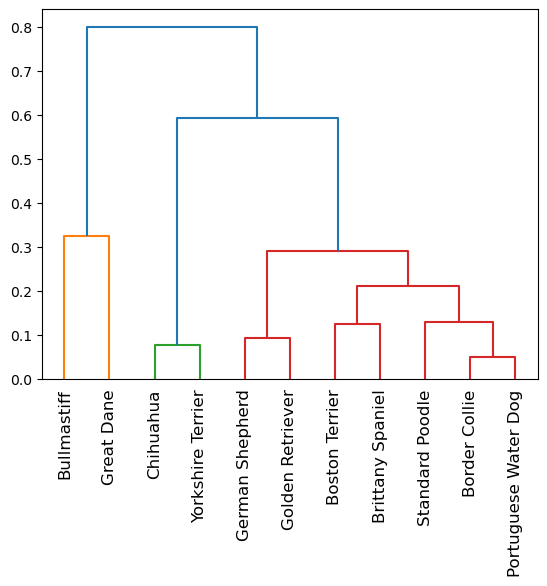

In [19]:
_ = dendrogram(Z, labels=pd.Index(df['breed']), leaf_rotation=90)                

**Napomena**: Funkcija za iscrtavanje dendograma očekuje da joj labele instanci budu prosleđene u obliku pandas <code>Index</code>-a. 

In [20]:
#II način:
#X = X.set_index(df['breed'])
#_ = dendrogram(Z, labels=X.index, leaf_rotation=90)    

#### Uporedni prikaz rezultata klasterovanja u odnosu na tip veze (min, max, avg)

Vršimo klasterovanje koristeći različite kriterijume za bliskost klastera (linkage) a zatim prikazujemo skup podataka tako da instance različitih klastera budu obojene različitom bojom. Za ocenu kvaliteta klasterovanja koristimo koeficijent siluete.

In [21]:
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score

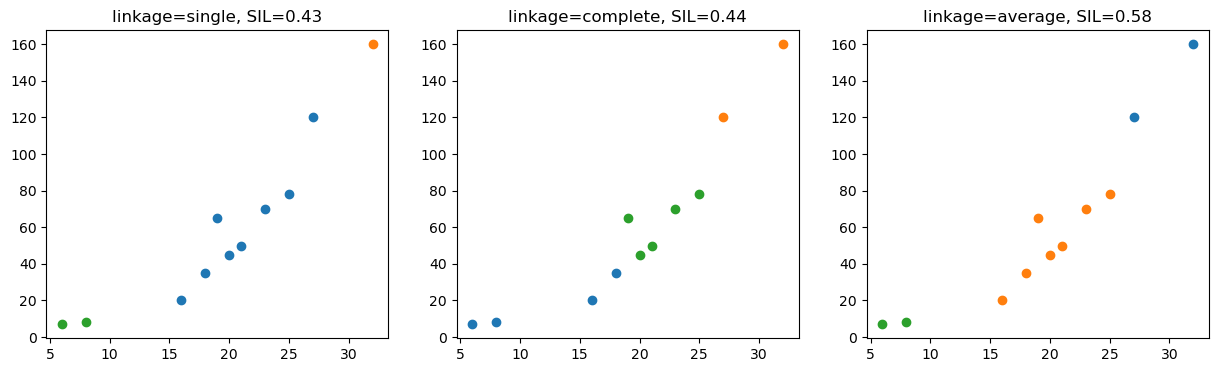

In [22]:
n_clusters = 3
linkages = ['single', 'complete', 'average']

fig = plt.figure(figsize=(15, 4))

for idx, linkage in enumerate(linkages):
    agg_clust = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    agg_clust.fit(X)
    
    fig.add_subplot(1, len(linkages), idx+1)
    
    for cluster_label in range(n_clusters):
        cluster_instances = df[agg_clust.labels_ == cluster_label]
        plt.scatter(cluster_instances['height'], cluster_instances['weight'])
    
    silhouette = silhouette_score(X, agg_clust.labels_)
    plt.title(f'linkage={linkage}, SIL={round(silhouette, 2)}')

Možemo primetiti da smo koristeći prosečnu vezu za određivanje bliskosti klastera dobili iste rezultate kao sa K-Means metodom.

## Klasterovanje zasnovano na gustini

Algoritam **DBSCAN** (eng. *Density-Based Spatial Clustering of Application with Noise*) pronalazi klastere na osnovu gustine instanci, odnosno, prepoznaje regione visoke gustine koji su međusobno razdvojeni regionima niske gustine.  Prednost ovog algoritma je to što može da pronađe klastere proizvoljnog oblika. Još jedna prednost ovog algoritma je u tome što ima mogućnost identifikovanja odudarajućih podataka (noise). Za razliku od prethodnih algoritama, DBSCAN algoritam ne zahteva da svaka instanca mora biti deo nekog klastera, već se instance koje su daleko od svih ostalih instanci (odudarajući podaci) podvode pod šum i izostavljaju iz klasterovanja

Prilikom primene algoritma DBSCAN moraju se zadati sledeći parametri kojima se definiše mera gustine instanci:
- <code>eps</code> - određuje $\epsilon$-okolinu instanci, tj. prag za rastojanje suseda; dve instance su susedne ako im je rastojanje $\leq \epsilon$ 
- <code>min_samples</code> - prag za broj suseda instanci u njegovoj $\epsilon$-okolini

Na osnovu ova dva parametra, za svaku instancu skupa se određuje tip:
- ***instance u jezgru klastera*** - instanca je u jezgru klastera ako je broj njenih suseda na rastojanju $\leq$ <code>eps</code> barem <code>min_samples</code>, tj. njena $\epsilon$-okolina sadrži barem <code>min_samples</code> instanci
- ***instance na granici klastera*** - instanca nije u jezgru klastera, ali je na rastojanju do <code>eps</code> od neke instance koja je u jezgru klastera, tj. u njenoj $\epsilon$-okolini se nalazi bar jedna instanca koja pripada jezgru nekog klastera
- ***šum*** - instanca koja nije ni u jezgru ni na granici klastera; ove instance neće biti pridružene nijednom klasteru

<img src='assets/DBSCAN.png' width='55%'>

Koraci za DBSCAN su opisani u algoritmu 2.

$$
\begin{array}{ll}
\textbf{Algoritam 2: } \textit{DBSCAN} \\
\hline
1: \text{Za svaku instancu izvršiti kategorizaciju: u jezgru, na granici ili šum.}\\
2: \text{Eliminisati instance koje su kategorisane kao šum.}\\
3: \text{Povezati sve instance u jezgru koje su na medusobnom rastojanju do }\texttt{eps}\text{.}\\
4: \text{Napraviti poseban klaster za svaku grupu instanci u jezgru koje su povezane.}\\
5: \text{Svaku instancu na granici pridružiti klasteru kojem pripada instanca u jezgru u čijem je susedstvu ta instanca na granici.}\\
\hline
\end{array}
$$

In [23]:
from sklearn.cluster import DBSCAN

In [24]:
dbscan = DBSCAN(eps=0.1, min_samples=2)

In [25]:
dbscan.fit(X)

,eps,0.1
,min_samples,2
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


Obeležja klastera pridružena instancama se mogu dobiti kroz `labels_` atribut naučenog modela (ova klasa nema metod `predict`).

In [26]:
dbscan.labels_

array([ 0, -1, -1, -1,  1,  2,  2, -1,  0, -1,  1])

Instance koje su algoritmom prepoznate kao šum imaju pridruženu labelu -1. 

In [27]:
set(dbscan.labels_)

{-1, 0, 1, 2}

Broj rezultujućih klastera:

In [28]:
n_clusters = len(set(dbscan.labels_)) - 1
n_clusters

3

Optimalne vrednosti za parametre <code>eps</code> i <code>min_samples</code> određujemo tako što pratimo ponašanje modela za različite vrednosti ovih parametara, a potom odaberemo najoptimalniju. Za svaku kombinaciju parametara ocenjujemo kvalitet klasterovanja u terminima koeficijenta siluete.

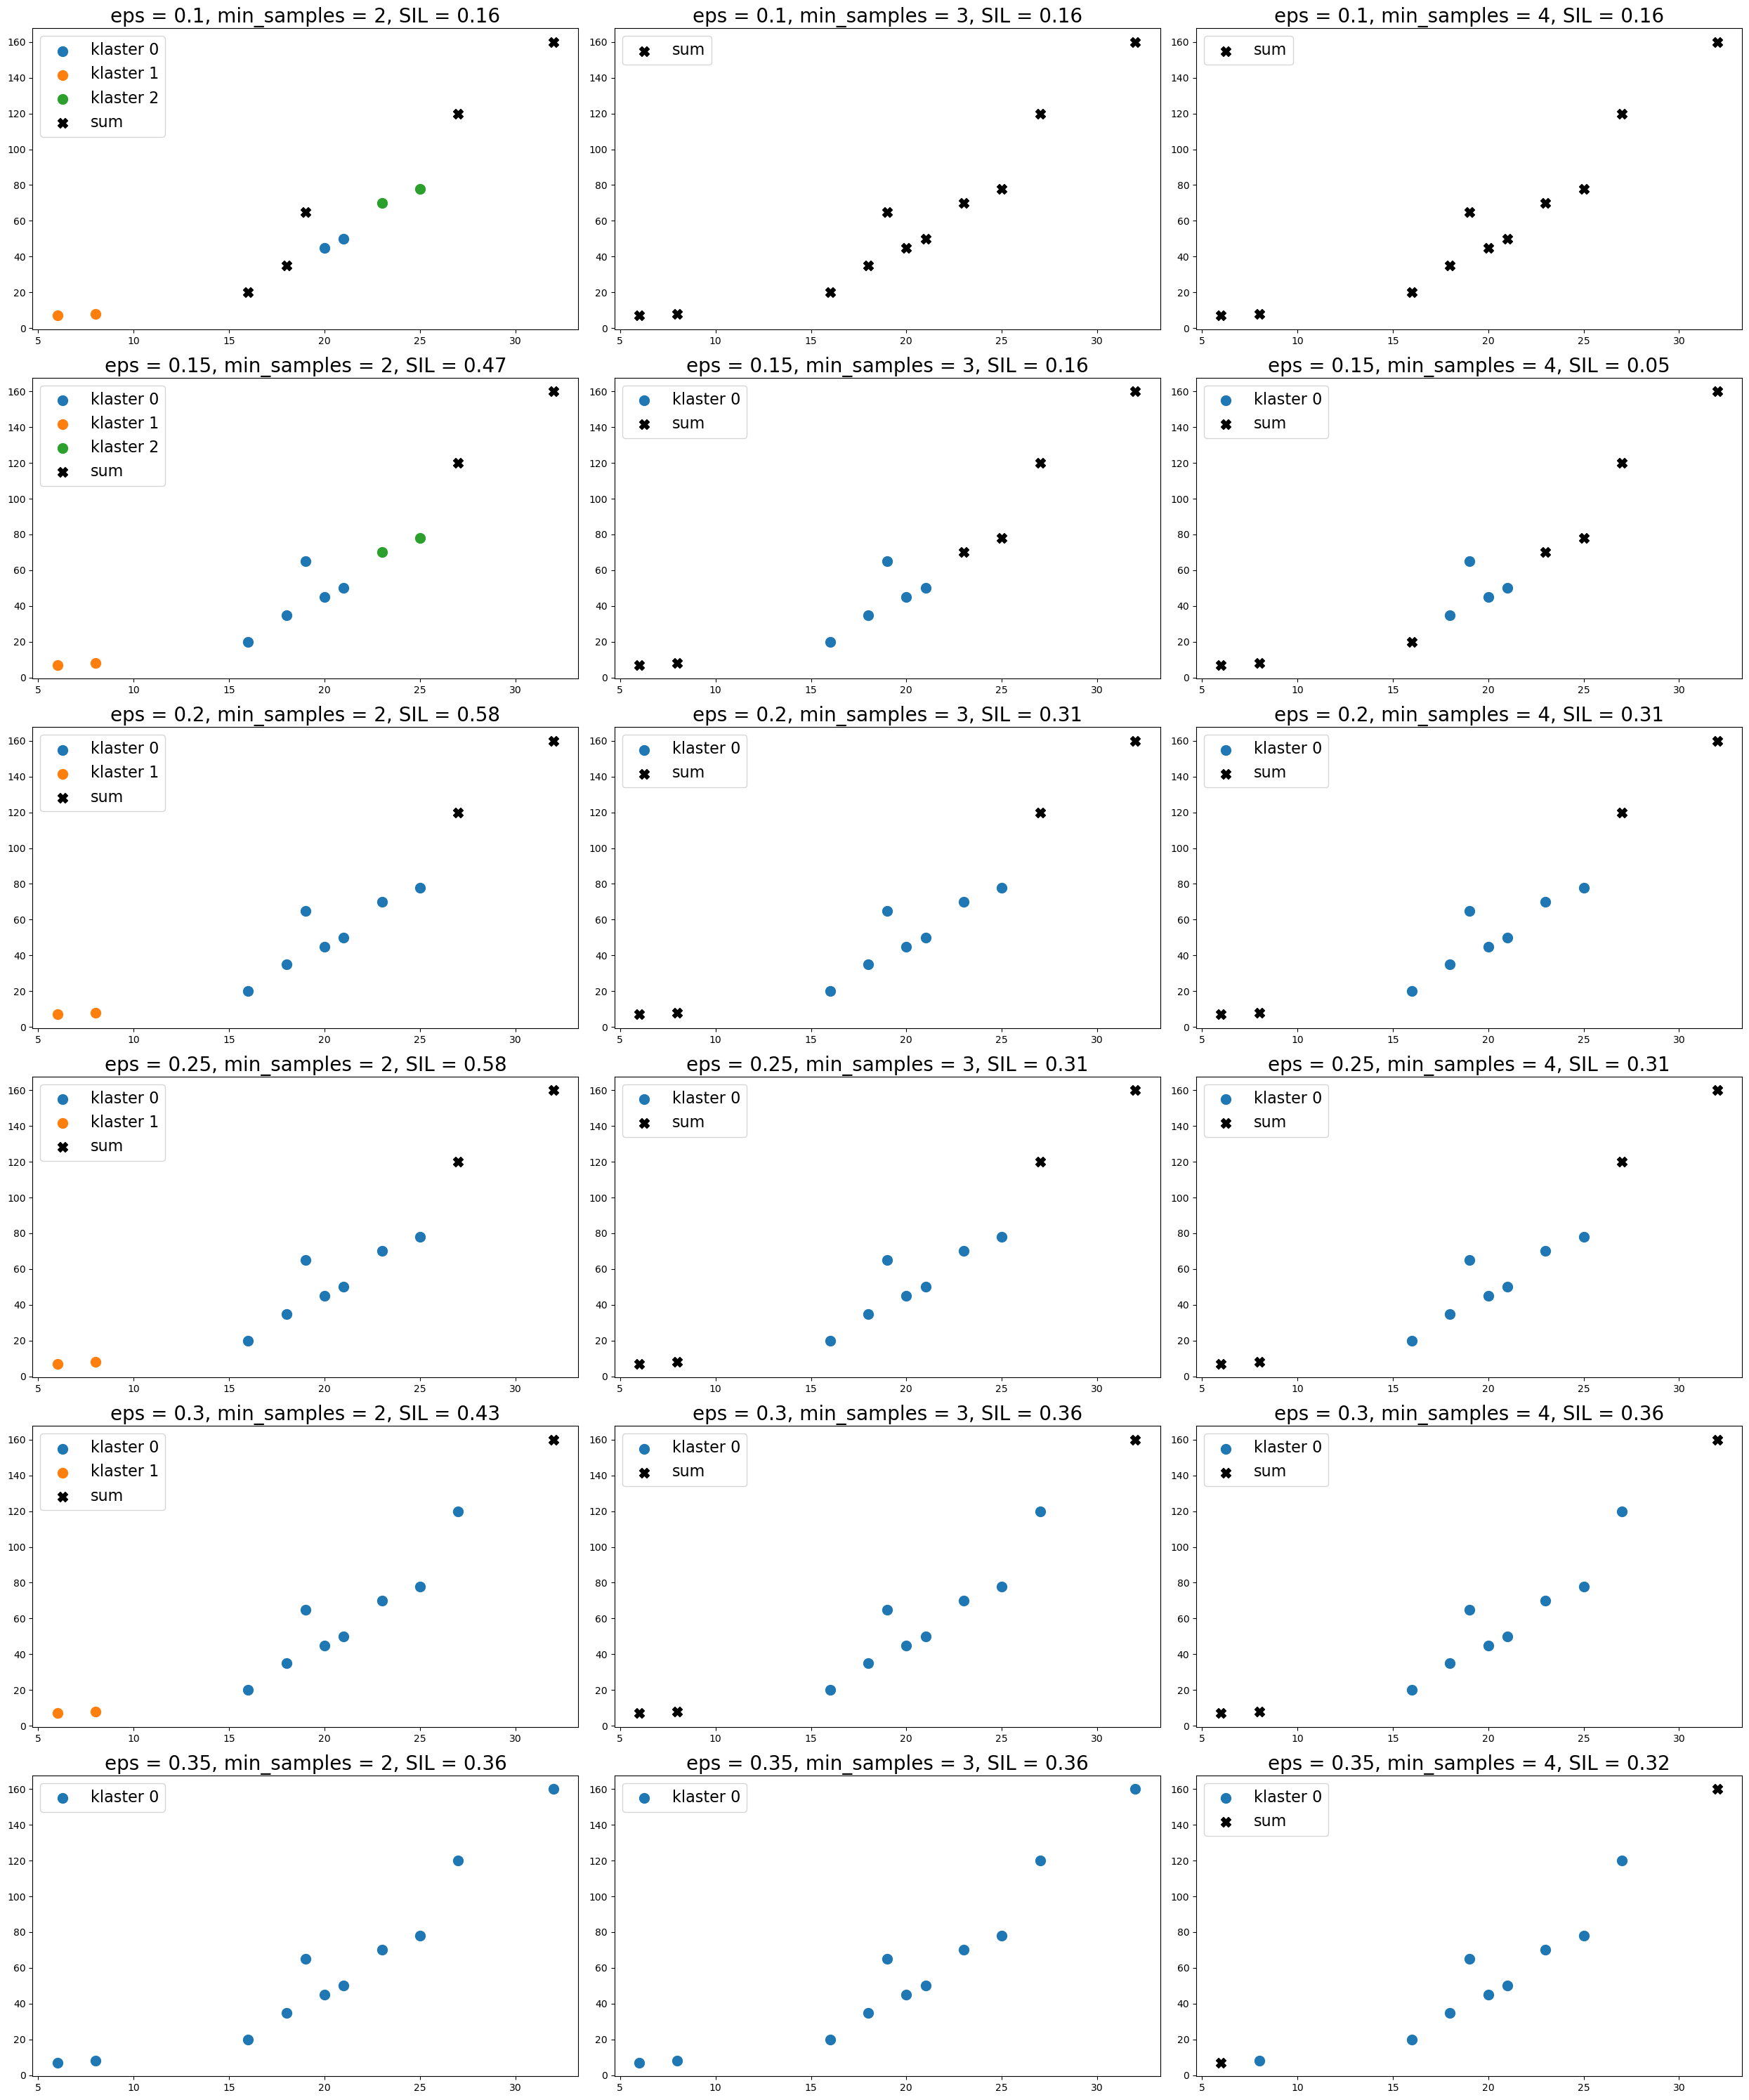

In [29]:
min_samples = 2
eps_values = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
min_samples_values = range(2,5)

fig = plt.figure(figsize=(25,30))

idx = 1
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(X)

        fig.add_subplot(len(eps_values), len(min_samples_values), idx)
        idx += 1

        for cluster_label in set(dbscan.labels_):
            cluster = df[dbscan.labels_ == cluster_label]
            if cluster_label == -1:
                plt.scatter(cluster['height'], cluster['weight'], marker='X', color='black', label='sum', s=100)
            else:
                plt.scatter(cluster['height'], cluster['weight'], label=f'klaster {cluster_label}', s=100)

        plt.legend(fontsize=16)
        
        if len(set(dbscan.labels_)) == 1:
            s = None
        else:
            silhouette = silhouette_score(X, dbscan.labels_)
        
        plt.title(f'eps = {eps}, min_samples = {min_samples}, SIL = {round(silhouette, 2)}', fontsize=20)
        
plt.tight_layout()

Možemo primetiti da velike vrednosti za <code>min_samples</code> dovode do toga da svaka instanca bude kategorisana ko šum, dok velike vrednosti za  <code>eps</code> rezultuju time da sve instance budu grupisane u jedan klaster.